# 📊 ScoutIQ — 01 · Data Understanding & Cleaning
---
**ScoutIQ Football Intelligence Platform** | Data Science Lifecycle · Notebook 1 of 3

### Objectives
1. Load and audit the raw FIFA football-team dataset
2. Perform a comprehensive data quality assessment
3. Identify and resolve data type issues and anomalies
4. Engineer the initial feature set and apply preprocessing
5. Produce clean, model-ready CSVs for downstream notebooks

> *Dataset: 1,000 international football team match records (train) · 250 (test)*  
> *Target: `winner` — binary (0 = loss/draw, 1 = win)*


In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1421',
    'axes.facecolor':    '#111827',
    'axes.edgecolor':    '#1e2a3a',
    'axes.labelcolor':   '#94a3b8',
    'xtick.color':       '#64748b',
    'ytick.color':       '#64748b',
    'text.color':        '#f1f5f9',
    'grid.color':        '#1e2a3a',
    'grid.linewidth':    0.6,
    'axes.grid':         True,
    'figure.dpi':        110,
    'font.family':       'DejaVu Sans',
})

# Accent palette
C_GREEN  = '#00e676'
C_BLUE   = '#2979ff'
C_GOLD   = '#ffd600'
C_RED    = '#ff1744'
C_CYAN   = '#00e5ff'
C_ORANGE = '#ff6d00'
C_MUTED  = '#475569'

CONF_COLORS = {
    'UEFA':     C_BLUE,
    'CONMEBOL': C_GREEN,
    'CAF':      C_GOLD,
    'CONCACAF': C_CYAN,
    'AFC':      C_ORANGE,
    'OFC':      '#ab47bc',
}

print('✅ Imports complete')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')


✅ Imports complete
   pandas 3.0.2 | numpy 2.4.4


## 1 · Load the Dataset
Load train and test CSVs and perform the first-look audit.


In [2]:
# ── Load Data ────────────────────────────────────────────────────────────────
train = pd.read_csv('../data/raw/fifa_matches_train.csv')
test  = pd.read_csv('../data/raw/fifa_matches_test.csv')

print('━' * 55)
print(f'  TRAIN  →  {train.shape[0]:>5} rows × {train.shape[1]:>2} columns')
print(f'  TEST   →  {test.shape[0]:>5} rows × {test.shape[1]:>2} columns')
print('━' * 55)
print()
print('Column names:')
for i, col in enumerate(train.columns, 1):
    print(f'  {i:>2}. {col}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TRAIN  →   1000 rows × 26 columns
  TEST   →    250 rows × 25 columns
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Column names:
   1. team_name
   2. country_code
   3. confederation
   4. fifa_rank
   5. fifa_points
   6. wins_last_10_matches
   7. losses_last_10_matches
   8. draws_last_10_matches
   9. win_rate_last_year
  10. goals_scored_avg
  11. goals_conceded_avg
  12. clean_sheets_last_10
  13. shots_per_game
  14. shots_on_target_ratio
  15. avg_player_rating
  16. star_players_count
  17. market_value_million_eur
  18. experience_avg_caps
  19. coach_experience_years
  20. recent_form_score
  21. possession_avg
  22. passing_accuracy
  23. host_advantage
  24. travel_distance_avg
  25. climate_similarity_score
  26. winner


In [3]:
# ── Head Sample ──────────────────────────────────────────────────────────────
print('── First 5 rows of Training Data ──')
train.head()


── First 5 rows of Training Data ──


,team_name,country_code,confederation,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,...,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
0,Poland,POL,UEFA,18,1675.2,5,4,1,0.520,1.11,...,256.0,26,10,6.5,47.3,76.8,0,6.2,0.61,1
1,Brazil,BRA,CONMEBOL,8,1831.2,7,2,1,0.690,2.31,...,1174.0,53,25,8.2,55.2,87.4,0,6.7,0.70,1
2,Netherlands,NED,UEFA,6,1769.3,6,2,2,0.585,1.85,...,741.0,49,12,7.2,56.3,88.4,0,8.0,0.61,1
3,Germany,DEU,UEFA,17,1663.4,7,1,2,0.584,1.40,...,593.0,43,16,8.1,57.5,80.6,0,6.2,0.55,0
4,Nigeria,NGA,CAF,28,1476.6,3,5,2,0.390,0.95,...,236.0,21,1,3.1,45.1,72.5,0,8.6,0.48,0


In [4]:
# ── Data Types Audit ─────────────────────────────────────────────────────────
dtype_df = pd.DataFrame({
    'Column':    train.dtypes.index,
    'Dtype':     train.dtypes.values.astype(str),
    'Non-Null':  train.notnull().sum().values,
    'Null Count':train.isnull().sum().values,
    'Null %':    (train.isnull().mean() * 100).round(2).values,
    'Unique':    train.nunique().values,
    'Sample Val':train.iloc[0].values,
})
print('Data Type Summary:')
print(dtype_df.to_string(index=False))


Data Type Summary:
                  Column   Dtype  Non-Null  Null Count  Null %  Unique Sample Val
               team_name     str      1000           0     0.0      49     Poland
            country_code     str      1000           0     0.0      49        POL
           confederation     str      1000           0     0.0       6       UEFA
               fifa_rank   int64      1000           0     0.0      50         18
             fifa_points float64      1000           0     0.0     904     1675.2
    wins_last_10_matches   int64      1000           0     0.0       9          5
  losses_last_10_matches   int64      1000           0     0.0       8          4
   draws_last_10_matches   int64      1000           0     0.0       6          1
      win_rate_last_year float64      1000           0     0.0     501       0.52
        goals_scored_avg float64      1000           0     0.0     219       1.11
      goals_conceded_avg float64      1000           0     0.0     174       0.

## 2 · Data Quality Assessment

Systematic checks for missing values, duplicates, range violations, and target integrity.


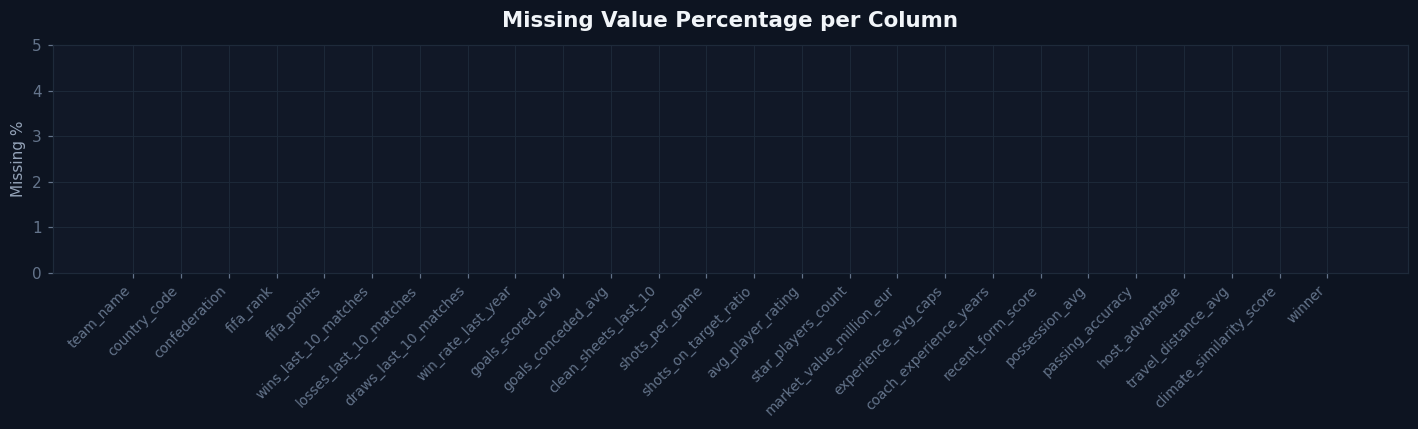

✅ PERFECT: Zero missing values across all columns!


In [5]:
# ── Missing Values Visualisation ─────────────────────────────────────────────
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)

fig, ax = plt.subplots(figsize=(13, 4))
colors = [C_RED if p > 10 else C_GOLD if p > 0 else C_GREEN for p in missing_pct.values]
bars = ax.bar(missing_pct.index, missing_pct.values, color=colors, edgecolor='none', linewidth=0)
ax.set_title('Missing Value Percentage per Column', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Missing %')
ax.set_ylim(0, max(missing_pct.max() + 2, 5))
plt.xticks(rotation=45, ha='right', fontsize=9)

# Annotate max
if missing_pct.max() > 0:
    idx = missing_pct.idxmax()
    ax.annotate(f'{missing_pct.max():.1f}%', xy=(idx, missing_pct.max()),
                xytext=(0, 8), textcoords='offset points', ha='center',
                color=C_RED, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

if missing.sum() == 0:
    print('✅ PERFECT: Zero missing values across all columns!')
else:
    print(f'⚠️  {missing.sum()} missing values found:')
    print(missing[missing > 0])


In [6]:
# ── Duplicate Check ──────────────────────────────────────────────────────────
dups = train.duplicated().sum()
full_dups = train.duplicated(keep=False).sum()
print(f'Exact duplicate rows   : {dups}')
print(f'Rows in duplicate pairs: {full_dups}')
print()

# ── Constant / Near-Constant Columns ─────────────────────────────────────────
low_var = [c for c in train.select_dtypes(include='number').columns
           if train[c].std() < 0.001 and c != 'winner']
print(f'Constant numeric columns: {low_var if low_var else "None ✅"}')

# ── ID / String columns ───────────────────────────────────────────────────────
str_cols = train.select_dtypes(include='object').columns.tolist()
print(f'String columns (need encoding): {str_cols}')


Exact duplicate rows   : 0
Rows in duplicate pairs: 0

Constant numeric columns: None ✅
String columns (need encoding): ['team_name', 'country_code', 'confederation']


In [7]:
# ── Range Validation for Key Metrics ─────────────────────────────────────────
checks = {
    'fifa_rank':             (1,   200),
    'avg_player_rating':     (50,  100),
    'win_rate_last_year':    (0.0, 1.0),
    'shots_on_target_ratio': (0.0, 1.0),
    'possession_avg':        (20,  80),
    'passing_accuracy':      (50,  100),
    'climate_similarity_score': (0.0, 1.0),
    'recent_form_score':     (0,   10),
}

header = '{:<30} {:>8} {:>8} {:>18} {:>8}'.format('Column','Min','Max','Expected','Status')
print(header)
print('─' * 80)
all_ok = True
for col, (lo, hi) in checks.items():
    actual_min = train[col].min()
    actual_max = train[col].max()
    ok = (actual_min >= lo) and (actual_max <= hi)
    all_ok = all_ok and ok
    status = '✅' if ok else '⚠️ '
    print(f'{col:<30} {actual_min:>8.2f} {actual_max:>8.2f} [{lo:>4}, {hi:>4}]  {status}')

print()
print('✅ All range checks passed!' if all_ok else '⚠️  Some range violations detected — investigate above.')


Column                              Min      Max           Expected   Status
────────────────────────────────────────────────────────────────────────────────
fifa_rank                          1.00    50.00 [   1,  200]  ✅
avg_player_rating                 70.00    90.00 [  50,  100]  ✅
win_rate_last_year                 0.20     0.85 [ 0.0,  1.0]  ✅
shots_on_target_ratio              0.22     0.55 [ 0.0,  1.0]  ✅
possession_avg                    40.10    67.90 [  20,   80]  ✅
passing_accuracy                  70.00    94.90 [  50,  100]  ✅
climate_similarity_score           0.25     0.95 [ 0.0,  1.0]  ✅
recent_form_score                  0.00    10.00 [   0,   10]  ✅

✅ All range checks passed!


## 3 · Statistical Summary


In [8]:
# ── Descriptive Statistics ───────────────────────────────────────────────────
desc = train.describe().T
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(3)  # coefficient of variation
desc = desc[['count','mean','std','min','25%','50%','75%','max','cv']]
print('Statistical Summary (numeric columns):')
print(desc.round(3).to_string())


Statistical Summary (numeric columns):
                           count      mean      std       min       25%       50%       75%      max     cv
fifa_rank                 1000.0    22.603   14.373     1.000     9.000    21.000    34.000    50.00  0.636
fifa_points               1000.0  1657.906  148.914  1400.400  1541.525  1651.000  1768.975  1999.50  0.090
wins_last_10_matches      1000.0     4.899    2.302     1.000     3.000     5.000     7.000     9.00  0.470
losses_last_10_matches    1000.0     3.360    1.909     0.000     2.000     3.000     5.000     7.00  0.568
draws_last_10_matches     1000.0     1.817    1.379     0.000     1.000     2.000     3.000     5.00  0.759
win_rate_last_year        1000.0     0.520    0.164     0.201     0.401     0.528     0.656     0.85  0.316
goals_scored_avg          1000.0     1.467    0.538     0.500     1.070     1.410     1.860     2.80  0.367
goals_conceded_avg        1000.0     1.186    0.427     0.410     0.880     1.120     1.450     2

In [9]:
# ── Skewness & Kurtosis ──────────────────────────────────────────────────────
num_cols = train.select_dtypes(include='number').columns.drop('winner')
skew_df = pd.DataFrame({
    'Skewness': train[num_cols].skew().round(3),
    'Kurtosis': train[num_cols].kurtosis().round(3),
}).sort_values('Skewness', key=abs, ascending=False)

print('Skewness & Kurtosis (sorted by |skew|):')
print(skew_df.to_string())
print()
high_skew = skew_df[skew_df['Skewness'].abs() > 1.0]
if not high_skew.empty:
    print(f'⚠️  Highly skewed features (|skew| > 1): {list(high_skew.index)}')
    print('   → Will apply log1p transform to market_value_million_eur')


Skewness & Kurtosis (sorted by |skew|):
                          Skewness  Kurtosis
host_advantage               3.603    11.001
market_value_million_eur     0.924    -0.147
coach_experience_years       0.639    -0.246
goals_conceded_avg           0.481    -0.476
goals_scored_avg             0.394    -0.548
clean_sheets_last_10         0.385    -0.467
draws_last_10_matches        0.382    -0.656
fifa_points                  0.330    -0.735
experience_avg_caps          0.268    -0.548
fifa_rank                    0.260    -1.116
shots_per_game               0.250    -0.850
possession_avg               0.238    -0.660
star_players_count           0.219    -0.639
passing_accuracy             0.213    -0.809
avg_player_rating            0.203    -0.948
shots_on_target_ratio        0.188    -0.600
losses_last_10_matches       0.162    -0.883
travel_distance_avg         -0.148     0.381
climate_similarity_score    -0.038    -0.329
recent_form_score            0.031    -0.691
win_rate_last_y

## 4 · Target Variable Analysis


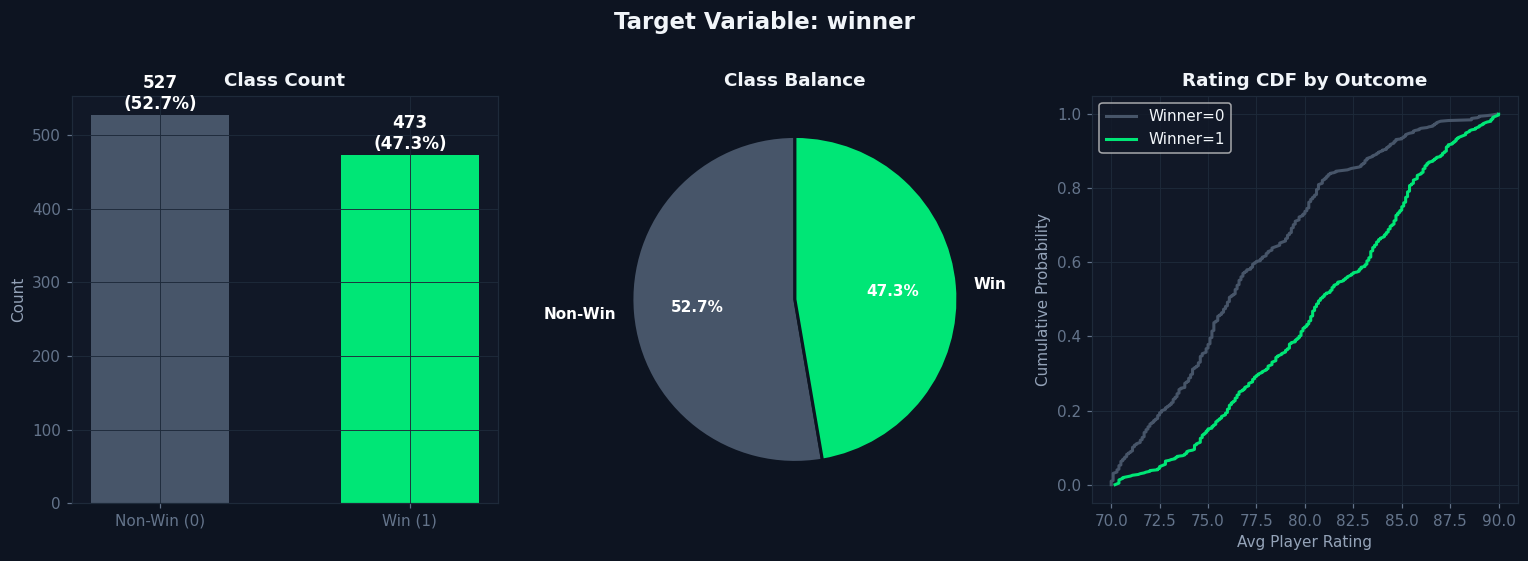

Class Balance: 47.3% wins | 52.7% non-wins
✅ Reasonably balanced — no resampling required.


In [10]:
# ── Target Distribution ──────────────────────────────────────────────────────
vc = train['winner'].value_counts()
pct = train['winner'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Bar chart
axes[0].bar(['Non-Win (0)', 'Win (1)'], vc.values,
            color=[C_MUTED, C_GREEN], edgecolor='none', width=0.55)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 8, str(v) + '\n(' + f'{pct[i]:.1f}' + '%)', ha='center',
                 fontweight='bold', color='white', fontsize=11)
axes[0].set_title('Class Count', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie
axes[1].pie(vc.values, labels=['Non-Win', 'Win'],
            colors=[C_MUTED, C_GREEN], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': '#0d1421', 'linewidth': 2},
            textprops={'color': 'white', 'fontweight': 'bold'})
axes[1].set_title('Class Balance', fontweight='bold')

# Cumulative distribution by class
for label, color in [(0, C_MUTED), (1, C_GREEN)]:
    subset = train[train['winner'] == label]['avg_player_rating'].sort_values()
    axes[2].plot(subset.values, np.linspace(0, 1, len(subset)),
                 color=color, linewidth=2, label=f'Winner={label}')
axes[2].set_title('Rating CDF by Outcome', fontweight='bold')
axes[2].set_xlabel('Avg Player Rating')
axes[2].set_ylabel('Cumulative Probability')
axes[2].legend()

plt.suptitle('Target Variable: winner', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Class Balance: {pct[1]:.1f}% wins | {pct[0]:.1f}% non-wins')
print('✅ Reasonably balanced — no resampling required.')


## 5 · Feature Engineering
Build 10 football-domain features that add modelling signal beyond the raw columns.


In [11]:
# ── Apply Feature Engineering ────────────────────────────────────────────────
from data_preprocessing import clean_and_process, save_processed

train_fe = clean_and_process(train.copy(), is_train=True)
test_fe  = clean_and_process(test.copy(),  is_train=False)

new_features = [
    'points_per_match_last_10', 'goal_difference_avg', 'performance_index',
    'value_per_cap', 'dominance_score', 'shot_quality', 'defensive_solidity',
    'log_market_value',
]

print('Feature Engineering Summary')
print('─' * 60)
for feat in new_features:
    if feat in train_fe.columns:
        print(f'  ✅ {feat:<35}  mean={train_fe[feat].mean():.3f}  std={train_fe[feat].std():.3f}')
    else:
        print(f'  ❌ {feat} — NOT FOUND')

print()
print(f'Raw columns  : {train.shape[1]}')
print(f'After FE     : {train_fe.shape[1]}')
print(f'New features : {train_fe.shape[1] - train.shape[1]}')


2026-05-26 06:48:47,220 - INFO - Feature engineering complete — added 10 derived features


2026-05-26 06:48:47,235 - INFO - Feature engineering complete — added 10 derived features


Feature Engineering Summary
────────────────────────────────────────────────────────────
  ✅ points_per_match_last_10             mean=1.636  std=0.611
  ✅ goal_difference_avg                  mean=0.282  std=0.901
  ✅ performance_index                    mean=53.129  std=9.859
  ✅ value_per_cap                        mean=13.679  std=4.337
  ✅ dominance_score                      mean=66.539  std=5.985
  ✅ shot_quality                         mean=4.749  std=2.182
  ✅ defensive_solidity                   mean=0.262  std=0.177
  ✅ log_market_value                     mean=6.130  std=0.477

Raw columns  : 26
After FE     : 45
New features : 19


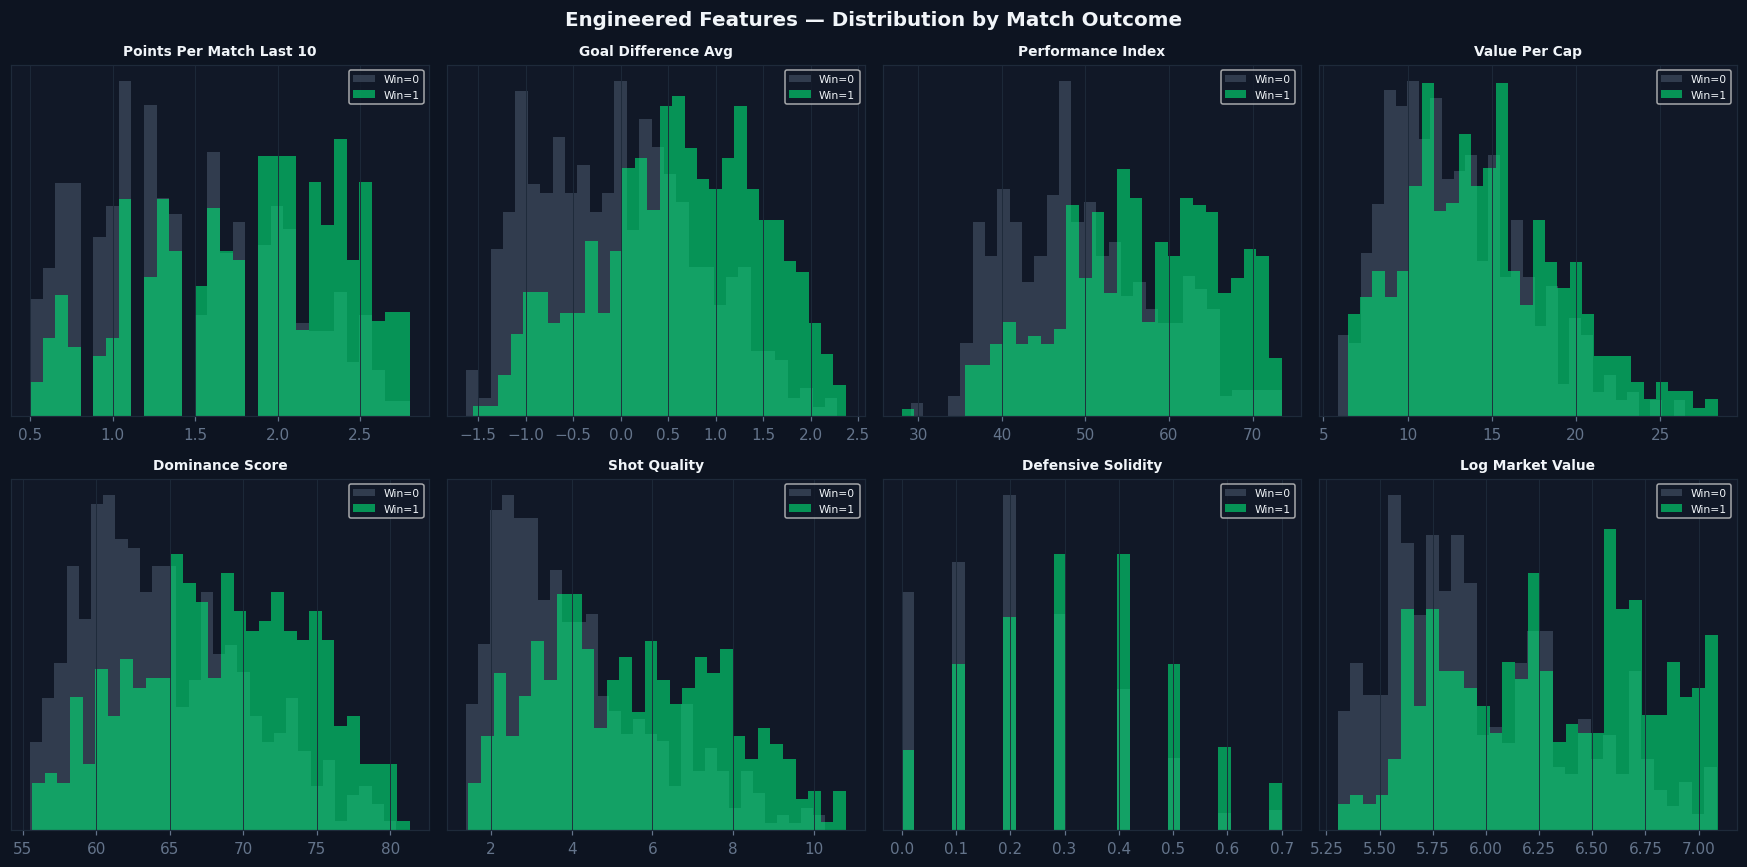

In [12]:
# ── Visualise Engineered Features ────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, feat in zip(axes.flat, new_features):
    if feat not in train_fe.columns:
        continue
    for label, color in [(0, C_MUTED), (1, C_GREEN)]:
        subset = train_fe[train_fe['winner'] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'Win={label}', density=True, edgecolor='none')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.suptitle('Engineered Features — Distribution by Match Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6 · Confederation & Categorical Encoding


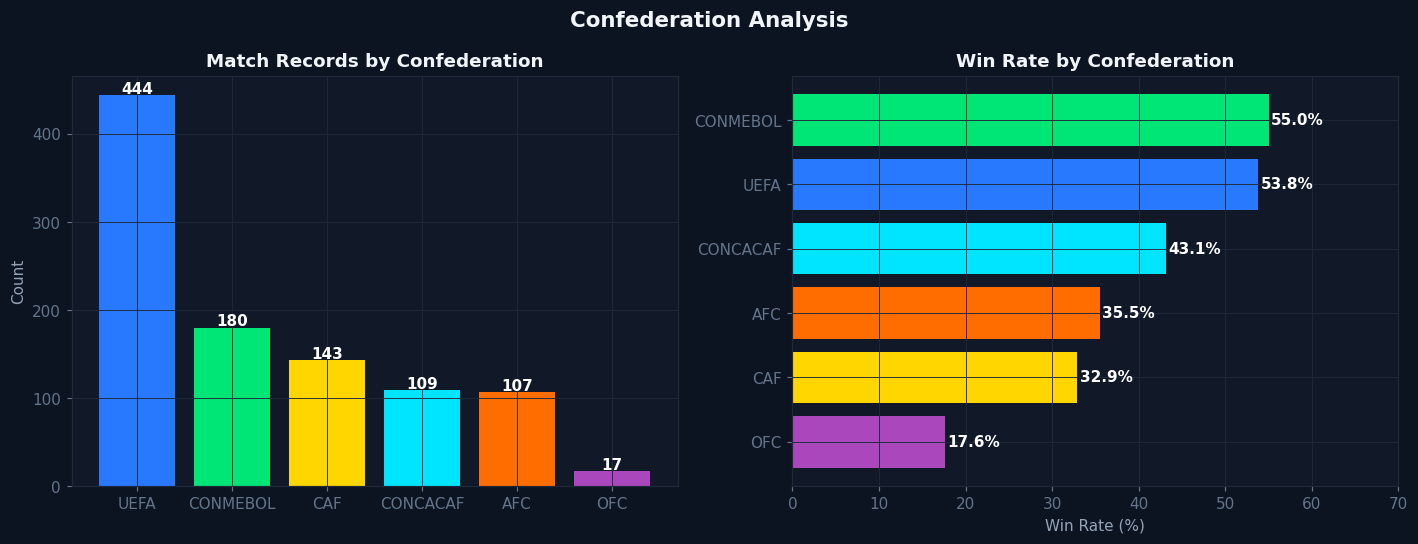

One-hot encoding applied to: confederation, rank_tier
  confederation dummies : ['conf_AFC', 'conf_CAF', 'conf_CONCACAF', 'conf_CONMEBOL', 'conf_OFC', 'conf_UEFA']
  rank_tier dummies     : ['rank_tier', 'rank_Developing', 'rank_Elite', 'rank_Mid', 'rank_Strong']


In [13]:
# ── Confederation Frequency ──────────────────────────────────────────────────
conf_counts = train['confederation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [CONF_COLORS.get(c, C_MUTED) for c in conf_counts.index]
axes[0].bar(conf_counts.index, conf_counts.values,
            color=colors, edgecolor='none', linewidth=0)
for i, v in enumerate(conf_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', color='white')
axes[0].set_title('Match Records by Confederation', fontweight='bold')
axes[0].set_ylabel('Count')

# Win rate by confederation
conf_wr = train.groupby('confederation')['winner'].mean().sort_values(ascending=False)
colors2 = [CONF_COLORS.get(c, C_MUTED) for c in conf_wr.index]
axes[1].barh(conf_wr.index[::-1], conf_wr.values[::-1] * 100,
             color=colors2[::-1], edgecolor='none')
for i, v in enumerate(conf_wr.values[::-1]):
    axes[1].text(v * 100 + 0.3, i, f'{v*100:.1f}%', va='center',
                 color='white', fontweight='bold', fontsize=10)
axes[1].set_title('Win Rate by Confederation', fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_xlim(0, 70)

plt.suptitle('Confederation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('One-hot encoding applied to: confederation, rank_tier')
conf_dummies = [c for c in train_fe.columns if c.startswith('conf_')]
rank_dummies  = [c for c in train_fe.columns if c.startswith('rank_')]
print(f'  confederation dummies : {conf_dummies}')
print(f'  rank_tier dummies     : {rank_dummies}')


## 7 · Data Quality Report & Save


In [14]:
# ── Final Quality Checks on Processed Data ───────────────────────────────────
from feature_engineering import get_all_feature_cols

feat_cols = get_all_feature_cols(train_fe)

print('Final Data Quality Report')
print('═' * 55)
print(f'  Train shape          : {train_fe.shape}')
print(f'  Test  shape          : {test_fe.shape}')
print(f'  Feature columns      : {len(feat_cols)}')
print(f'  Missing (train)      : {train_fe[feat_cols].isnull().sum().sum()}')
print(f'  Missing (test)       : {test_fe[[c for c in feat_cols if c in test_fe.columns]].isnull().sum().sum()}')
print(f'  Target balance       : {train_fe["winner"].mean()*100:.1f}% wins')
print(f'  Duplicate rows       : {train_fe.duplicated().sum()}')
print()
print('Feature column list:')
for i, f in enumerate(feat_cols, 1):
    print(f'  {i:>2}. {f}')


Final Data Quality Report
═══════════════════════════════════════════════════════
  Train shape          : (1000, 45)
  Test  shape          : (250, 44)
  Feature columns      : 40
  Missing (train)      : 0
  Missing (test)       : 0
  Target balance       : 47.3% wins
  Duplicate rows       : 0

Feature column list:
   1. fifa_rank
   2. fifa_points
   3. wins_last_10_matches
   4. losses_last_10_matches
   5. draws_last_10_matches
   6. win_rate_last_year
   7. goals_scored_avg
   8. goals_conceded_avg
   9. clean_sheets_last_10
  10. shots_per_game
  11. shots_on_target_ratio
  12. avg_player_rating
  13. star_players_count
  14. market_value_million_eur
  15. experience_avg_caps
  16. coach_experience_years
  17. recent_form_score
  18. possession_avg
  19. passing_accuracy
  20. host_advantage
  21. travel_distance_avg
  22. climate_similarity_score
  23. points_per_match_last_10
  24. goal_difference_avg
  25. performance_index
  26. value_per_cap
  27. dominance_score
  28. sho

In [15]:
# ── Save Processed Datasets ──────────────────────────────────────────────────
save_processed(train_fe, 'cleaned_train.csv')
save_processed(test_fe,  'cleaned_test.csv')

print('✅ Saved: data/processed/cleaned_train.csv')
print('✅ Saved: data/processed/cleaned_test.csv')
print()
print('─' * 55)
print('Notebook 01 COMPLETE ✅')
print('Next → 02_Professional_EDA_and_Insights.ipynb')


2026-05-26 06:48:49,545 - INFO - Saved processed data → /home/claude/ScoutIQ/data/processed/cleaned_train.csv


2026-05-26 06:48:49,554 - INFO - Saved processed data → /home/claude/ScoutIQ/data/processed/cleaned_test.csv


✅ Saved: data/processed/cleaned_train.csv
✅ Saved: data/processed/cleaned_test.csv

───────────────────────────────────────────────────────
Notebook 01 COMPLETE ✅
Next → 02_Professional_EDA_and_Insights.ipynb
